In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [14]:
df = pd.read_csv('homeprice.csv')
df.head()

,area,price,bedrooms
0,2600,550000,1
1,3000,570000,2
2,3200,600000,3
3,3600,650000,4
4,4000,700000,5


In [15]:
# scaling the data for making it ready for performing gradient descent , batch gradient descent, stochastic gradient descent and mini batch gradient descent
from sklearn.preprocessing import MinMaxScaler
sx = MinMaxScaler()
sy = MinMaxScaler()
scaled_x = sx.fit_transform(df.drop('price', axis='columns'))
scaled_x

array([[0.10344828, 0.        ],
       [0.24137931, 0.09090909],
       [0.31034483, 0.18181818],
       [0.44827586, 0.27272727],
       [0.5862069 , 0.36363636],
       [0.55172414, 0.45454545],
       [0.37931034, 0.54545455],
       [0.        , 0.63636364],
       [0.93103448, 0.72727273],
       [0.75862069, 0.81818182],
       [0.37931034, 0.90909091],
       [1.        , 1.        ]])

In [16]:
df.shape[0]

12

In [17]:
scaled_y = sy.fit_transform(df['price'].values.reshape(df.shape[0],1))
scaled_y

array([[0.16666667],
       [0.23333333],
       [0.33333333],
       [0.5       ],
       [0.66666667],
       [0.93333333],
       [0.5       ],
       [0.        ],
       [1.        ],
       [0.83333333],
       [0.5       ],
       [0.5       ]])

In [18]:
scaled_x.shape[1]

2

In [34]:
# fix the error in the batch gradient descent function and plot the cost function over epochs

def batch_gradient_descent(X, Y_true, epochs=100, learning_rate=0.01):
    num_of_features = X.shape[1]

    w = np.ones(num_of_features)
    b = 0
    total_samples = X.shape[0]
    cost_list = []
    epoch_list = []
    for i in range(epochs):
        Y_pred = np.dot( w, X.T) + b
        dw = -(2/total_samples) * np.dot(X.T, (Y_true - Y_pred))
        db = -(2/total_samples) * np.sum(Y_pred - Y_true)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        cost = np.mean(np.square(Y_true - Y_pred))

        if i % 10 == 0:
            cost_list.append(cost)
            epoch_list.append(i)
    plt.figure(figsize=(5,4))
    plt.plot(epoch_list, cost_list)
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.title("Cost Function over Epochs")
    plt.show()

    return w, b, cost_list, epoch_list

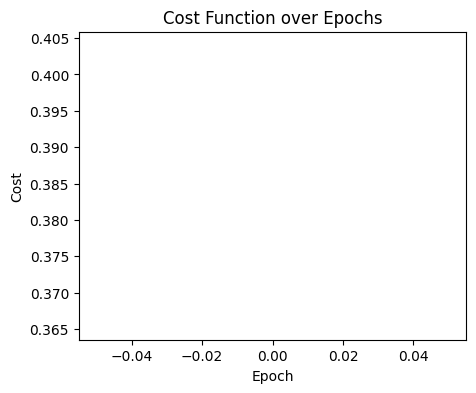

(array([0.97065321, 0.96511301]), np.float64(0.04662551154682311))

In [41]:
w,b,cost_list, epoch_list = batch_gradient_descent(scaled_x, scaled_y.reshape(scaled_y.shape[0],), epochs=5
                                                   , learning_rate=0.01)
w,b

In [44]:
def predict(area, bedrooms, w, b):
    scaledX = sx.transform([[area, bedrooms]])[0]

    scaled_price = w[0] * scaledX[0] + w[1] * scaledX[1] + b

    return sy.inverse_transform([[scaled_price]])[0][0]

predict(3000, 3, w, b)
    

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(636918.86179403)

In [53]:
# let's look at stochastic gradient descent and mini batch gradient descent in the next notebook
def stochastic_gradient_descent(X, Y_true, epochs=100, learning_rate=0.01):
    num_of_features = X.shape[1]

    w = np.ones(shape=(num_of_features))
    b = 0
    total_samples = X.shape[0]
    cost_list = []
    epoch_list = []
    for i in range(epochs):
        for j in range(total_samples):
            random_index = np.random.randint(0, total_samples-1)
            X_sample = X[random_index]
            Y_sample = Y_true[random_index]
            Y_pred = np.dot(w, X_sample.T) + b
            dw = -(2/total_samples) *( X_sample.T.dot(Y_sample - Y_pred))
            db = -(2/total_samples) * (Y_sample - Y_pred)
            w = w - learning_rate * dw
            b = b - learning_rate * db

        if i % 100 == 0:
            cost = np.mean(np.square(Y_true - (np.dot(w, X.T) + b)))
            cost_list.append(cost)
            epoch_list.append(i)

    plt.figure(figsize=(5,4))
    plt.plot(epoch_list, cost_list)
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.title("Cost Function over Epochs")
    plt.show()

    return w, b, cost_list, epoch_list

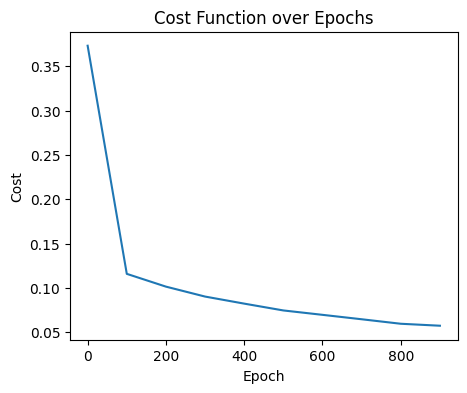

In [54]:
w,b,cost_list,epoch_list = stochastic_gradient_descent(scaled_x, scaled_y.reshape(scaled_y.shape[0],), epochs=1000, learning_rate=0.01)    